# Criando um modelo de evasão de Alunos

In [9]:
import pandas as pd
from sqlalchemy import create_engine
import seaborn as sns
import matplotlib.pyplot as plt


In [4]:
!pip install python-dotenv scikit-learn

  Using cached python_dotenv-1.0.1-py3-none-any.whl.metadata (23 kB)
Using cached python_dotenv-1.0.1-py3-none-any.whl (19 kB)


In [2]:
import os
from dotenv import load_dotenv

# Carrega as variáveis de ambiente do arquivo .env
load_dotenv(dotenv_path="../.env_dev")

True

In [3]:
def create_conn():
    # Defina os parâmetros de conexão
    db_user = os.getenv('DB_USER')
    db_password = os.getenv('DB_PASSWORD')
    db_host = os.getenv('DB_HOST')
    db_port = '5432'
    db_name = 'magic-steps'

    # Crie a URL de conexão
    connection_url = f'postgresql://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}'

    # Crie um engine do SQLAlchemy
    engine = create_engine(connection_url)
    return engine
engine = create_conn()

In [4]:
# Query para listar todas as tabelas
query = """
SELECT *
FROM magic_steps.aluno_nota_completo
"""

df = pd.read_sql_query(query, engine)
df.head()

,idaluno,idturma,motivoinativacao,nomedisciplina,notafase,nomefase,idfasenota,numerofase,idade,corraca,sexo,datasituacaoativo,datasituacaoinativo,datahoraefetivacaomatricula,diasmatriculado,inativo
0,3,210,None,MATEMÁTICA,4.5,DIAGNOSTICA 1,266,1,19.0,R,F,2022-01-01 00:00:00,2022-12-31 00:00:00,2022-01-20 00:00:00,345.0,False
1,3,210,None,PORTUGUÊS,5.5,DIAGNOSTICA 1,266,1,19.0,R,F,2022-01-01 00:00:00,2022-12-31 00:00:00,2022-01-20 00:00:00,345.0,False
2,3,210,None,INGLÊS,2.5,DIAGNOSTICA 1,266,1,19.0,R,F,2022-01-01 00:00:00,2022-12-31 00:00:00,2022-01-20 00:00:00,345.0,False
3,3,303,None,INGLÊS,2.5,DIAGNOSTICA 1,278,1,19.0,R,F,2022-01-01 00:00:00,2022-12-31 00:00:00,2022-02-28 00:00:00,306.0,False
4,3,210,None,PORTUGUÊS,4.0,1º SEMESTRE,267,2,19.0,R,F,2022-01-01 00:00:00,2022-12-31 00:00:00,2022-01-20 00:00:00,345.0,False


In [49]:
df.info(), df.shape

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 15021 entries, 0 to 15020
Data columns (total 17 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   idaluno                      15021 non-null  int64  
 1   idturma                      15021 non-null  int64  
 2   motivoinativacao             840 non-null    object 
 3   nomedisciplina               15021 non-null  object 
 4   notafase                     15021 non-null  float64
 5   nomefase                     15021 non-null  object 
 6   idfasenota                   15021 non-null  int64  
 7   numerofase                   15021 non-null  int64  
 8   idade                        15021 non-null  float64
 9   corraca                      15021 non-null  object 
 10  sexo                         15021 non-null  object 
 11  datasituacaoativo            15021 non-null  object 
 12  datasituacaoinativo          15021 non-null  object 
 13  datahoraefetivac

(None, (15021, 17))

In [7]:
# Configurações de visualização
sns.set_theme(style="whitegrid", palette="pastel")
sns.color_palette("pastel")

[(0.6313725490196078, 0.788235294117647, 0.9568627450980393),
 (1.0, 0.7058823529411765, 0.5098039215686274),
 (0.5529411764705883, 0.8980392156862745, 0.6313725490196078),
 (1.0, 0.6235294117647059, 0.6078431372549019),
 (0.8156862745098039, 0.7333333333333333, 1.0),
 (0.8705882352941177, 0.7333333333333333, 0.6078431372549019),
 (0.9803921568627451, 0.6901960784313725, 0.8941176470588236),
 (0.8117647058823529, 0.8117647058823529, 0.8117647058823529),
 (1.0, 0.996078431372549, 0.6392156862745098),
 (0.7254901960784313, 0.9490196078431372, 0.9411764705882353)]

### Distribuição das Notas dos Alunos

>Obs: Foi filtrado apenas os alunos com nota maior que zero, pois a base apresenta registros com notas negativas podendo ser provavelmente algum erro de sistema ou digitação.

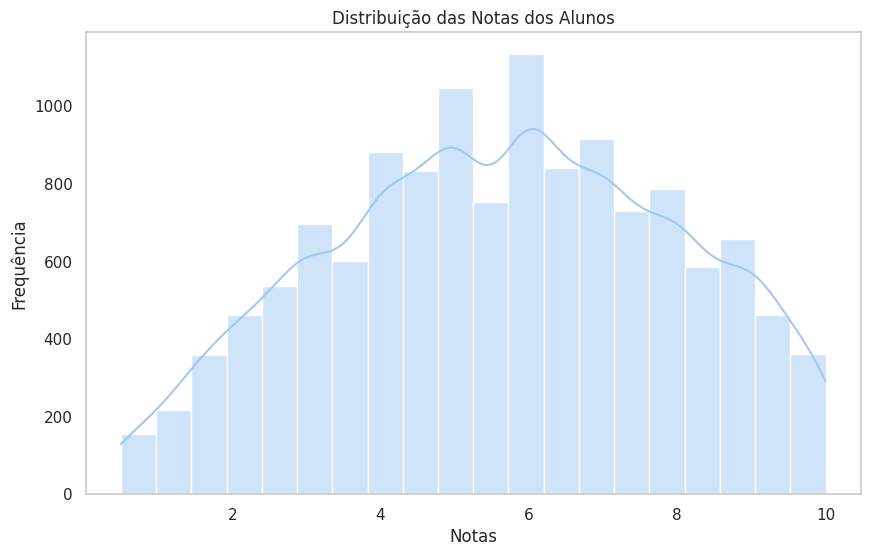

In [27]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df[df['notafase'] > 0], x='notafase', bins=20, kde=True)
plt.title('Distribuição das Notas dos Alunos')
plt.xlabel('Notas')
plt.ylabel('Frequência')
plt.grid()
plt.show()

### Analisando a relação entre o motivo de inativação e as notas


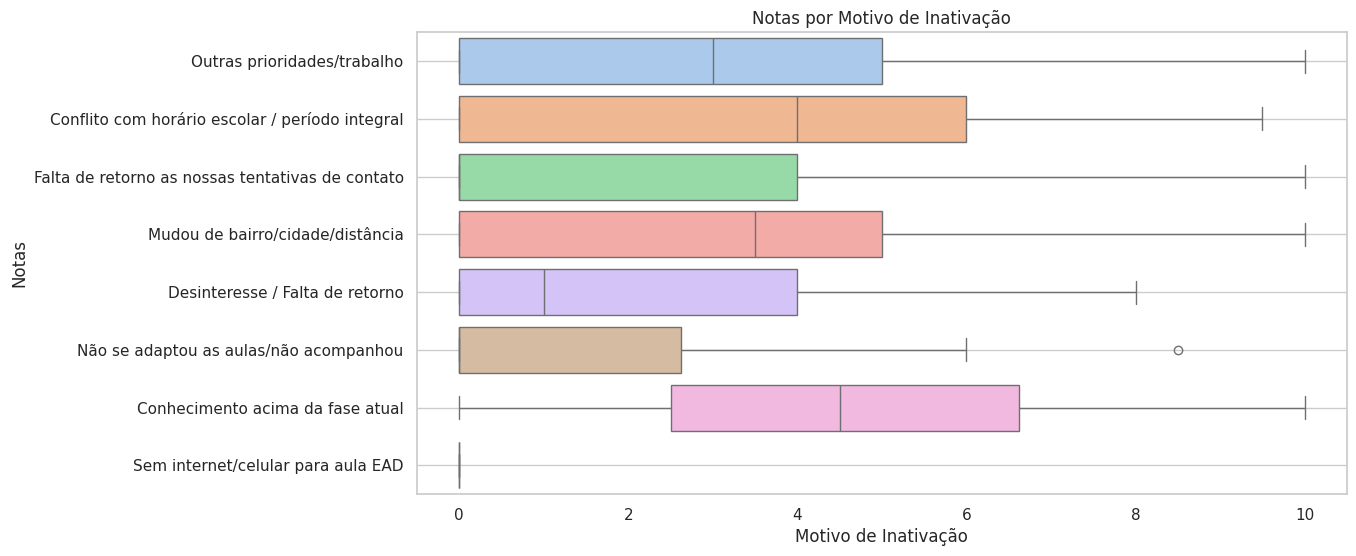

In [50]:
plt.figure(figsize=(12, 6))
sns.boxplot(y='motivoinativacao', x='notafase', data=df, hue='motivoinativacao',  palette='pastel')
plt.title('Notas por Motivo de Inativação')
plt.xlabel('Motivo de Inativação')
plt.ylabel('Notas')
plt.grid()
plt.legend().remove()

plt.show()

#### Features selecionadas

In [33]:
df[['idade', 'notafase', 'numerofase', 'diasmatriculado','inativo']]

,idade,notafase,numerofase,diasmatriculado,inativo
0,19.0,4.5,1,345.0,False
1,19.0,5.5,1,345.0,False
2,19.0,2.5,1,345.0,False
3,19.0,2.5,1,306.0,False
4,19.0,4.0,2,345.0,False
...,...,...,...,...,...
15016,14.0,8.5,4,112.0,False
15017,14.0,6.0,5,112.0,False
15018,14.0,4.5,5,112.0,False
15019,14.0,4.5,6,112.0,False


### Correlação entre Variáveis

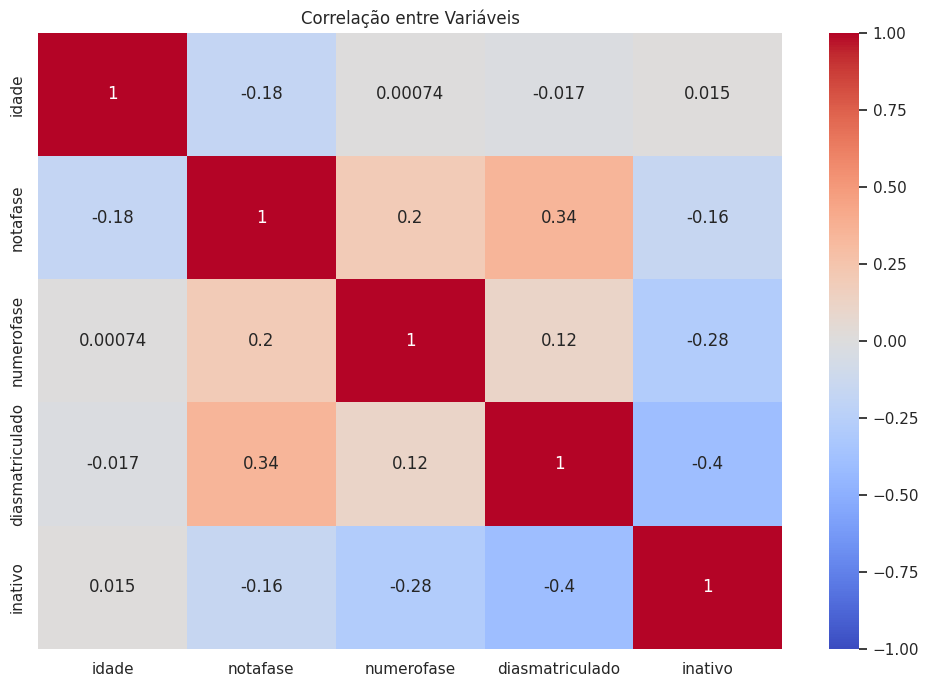

In [52]:
plt.figure(figsize=(12, 8))
sns.heatmap(df[['idade', 'notafase', 'numerofase', 'diasmatriculado','inativo']].corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlação entre Variáveis')
plt.show()


# Construindo o Modelo

Escolhemos o modelo de regressão logística, que é um modelo amplamente utilizado para problemas de classificação binária, como prever se um aluno irá ou não desistir. Esse modelo é capaz de estimar a probabilidade de um evento ocorrer, o que se alinha bem com nosso objetivo de prever a evasão.

In [53]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

features = ['idade', 'notafase', 'numerofase', 'diasmatriculado']

# Embaralhando o DataFrame
df_shuffled = df.sample(frac=1, random_state=42).reset_index(drop=True)

# Separarando as fetures e o target
X = df_shuffled[features]
y = df_shuffled['inativo']

# Dividindo entre treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalização dos dados
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Criar e treinar o modelo
model = LogisticRegression(random_state=42)
model.fit(X_train_scaled, y_train)

# Fazer previsão
y_pred = model.predict(X_test_scaled)



acurácia do modelo: 0.95
Relatório de classificação:
              precision    recall  f1-score   support

       False       0.97      0.98      0.97      2844
        True       0.51      0.38      0.44       161

    accuracy                           0.95      3005
   macro avg       0.74      0.68      0.70      3005
weighted avg       0.94      0.95      0.94      3005

Importância das características:
           feature  importância
2       numerofase     2.527002
3  diasmatriculado     1.646002
1         notafase     0.320757
0            idade     0.081603


## Avaliando o modelo


In [54]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Acurácia do modelo: {accuracy:.2f}")

acurácia do modelo: 0.95


In [55]:
print("Relatório de classificação:")
print(classification_report(y_test, y_pred))

Relatório de classificação:
              precision    recall  f1-score   support

       False       0.97      0.98      0.97      2844
        True       0.51      0.38      0.44       161

    accuracy                           0.95      3005
   macro avg       0.74      0.68      0.70      3005
weighted avg       0.94      0.95      0.94      3005



In [56]:
# Importancia das caracteristicas
feature_importance = pd.DataFrame({'feature': features, 'importância': abs(model.coef_[0])})
feature_importance = feature_importance.sort_values('importância', ascending=False)
print("Importância das características:")
print(feature_importance)

Importância das características:
           feature  importância
2       numerofase     2.527002
3  diasmatriculado     1.646002
1         notafase     0.320757
0            idade     0.081603


In [57]:
!pip install joblib


[notice] A new release of pip is available: 23.1.2 -> 24.2
[notice] To update, run: pip install --upgrade pip


### Salvando modelo para utilizar no streamlit

In [85]:
import joblib

joblib.dump(model, 'model.pkl')
joblib.dump(scaler, 'scaler.pkl')


['scaler.pkl']

### Filtrando os dados inativos para testar manualmente

In [71]:
col = [ 'idade', 'notafase', 'numerofase', 'diasmatriculado', 'inativo']
df[df['inativo'] == True][col].head()

,idade,notafase,numerofase,diasmatriculado,inativo
60,19.0,5.5,1,66.0,True
301,19.0,0.0,1,66.0,True
316,20.0,4.5,1,163.0,True
317,20.0,0.0,1,125.0,True
318,20.0,6.5,1,163.0,True


Testando o modelo salvo

In [86]:
model = joblib.load('model.pkl')
scaler = joblib.load('scaler.pkl')

# Fazer previsão com novos dados
novo_dado = pd.DataFrame({
    'idade': [19],
    'notafase': [5.5],
    'numerofase': [1],
    'diasmatriculado': [66]
})

novo_dado_scaler = scaler.transform(novo_dado)

previsao = model.predict(novo_dado_scaler)
print(previsao)
if previsao[0] == 1:
    print("O modelo prevê que o aluno ficará inativo.")
else:
    print("O modelo prevê que o aluno não ficará inativo.")


[ True]
O modelo prevê que o aluno ficará inativo.


# Conclusão

Após a modelagem dos dados e escolhermos novas features para o modelo percebemos um bom desempenho. Com isso podemos perceber que o desempenho do aluno tem grande influência na decisão em continuar ou desistir.